Part B - Artur; Model is Random Forest

# Q2 Supervised Text Classification

# Step 1 - libraries installation

In [4]:
#libraries installation
%pip install pandas scikit-learn

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

Note: you may need to restart the kernel to use updated packages.


# Step 2 - Loading and exploring the datasets

In [5]:
# load the training and testing CSV files
train_df = pd.read_csv('../Data/train_set.csv')
test_df = pd.read_csv('../Data/test_set.csv')

# print shape of the training and testing data
print(f"Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Testing set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

# check the distribution of sentiment classes in the training set
print("\n--- Sentiment Class Distribution (Training Data) ---")
print(train_df['Sentiment'].value_counts())

# print a preview of the training data
print("\n--- Training Data Preview ---")
train_df.head()

Training set: 107768 rows, 2 columns
Testing set: 26945 rows, 2 columns

--- Sentiment Class Distribution (Training Data) ---
Sentiment
positive    81835
negative    19791
neutral      6142
Name: count, dtype: int64

--- Training Data Preview ---


,Summary_clean,Sentiment
0,good product beautiful sound good packing chea...,positive
1,shown picture soft cute baby dress really liked,positive
2,great deal niece cloud nine quality also superb,positive
3,superb productthis second washing machine marq...,positive
4,dam masti like prodocts,positive


The datasets consist of a large corpus of pre-processed e-commerce reviews, split into training and testing subsets (approximately an 80/20 split). The data is highly focused, containing only two essential columns: Summary_clean, which holds the fully normalized and cleaned text of the customer reviews, and Sentiment, which serves as the target variable for our Random Forest classifier. The class distribution check confirms the presence of three distinct sentiment categories (Positive, Negative, Neutral), allowing us to proceed with a multiclass classification approach.

# Step 3 - Pipeline of Random Forest with Further Training.

In [6]:
# assign the text column as features (X) and the label column as targets (y)
X_train = train_df['Summary_clean']
y_train = train_df['Sentiment']
X_test = test_df['Summary_clean']
y_test = test_df['Sentiment']

# confirm the sizes of each split
print("--- Feature & Label Split ---")
print(f"X_train: {len(X_train)} samples | y_train: {len(y_train)} labels")
print(f"X_test: {len(X_test)} samples | y_test: {len(y_test)} labels")
print(f"\nLabel classes: {list(y_train.unique())}")

# build the pipeline with TF-IDF Vectorizer and Random Forest Classifier
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)) 
])

# train the Random Forest pipeline
print("\n--- Training Random Forest Pipeline ---")
rf_pipeline.fit(X_train, y_train)
print("Training complete!")

--- Feature & Label Split ---
X_train: 107768 samples | y_train: 107768 labels
X_test: 26945 samples | y_test: 26945 labels

Label classes: ['positive', 'negative', 'neutral']

--- Training Random Forest Pipeline ---
Training complete!


# Step 4 - Predicting

In [7]:
# make predictions on the testing set
print("--- Predicting on Test Data ---")
y_pred = rf_pipeline.predict(X_test)

# print the detailed classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# create a dataframe to view some sample predictions alongside actual labels
print("\n--- Sample Predictions ---")
results_df = pd.DataFrame({
    'Summary_clean': X_test, 
    'Actual_Sentiment': y_test, 
    'Predicted_Sentiment': y_pred
})
results_df.head(10)

--- Predicting on Test Data ---
--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.84      0.72      0.77      4949
     neutral       0.71      0.37      0.49      1540
    positive       0.91      0.98      0.94     20456

    accuracy                           0.89     26945
   macro avg       0.82      0.69      0.73     26945
weighted avg       0.89      0.89      0.89     26945


--- Sample Predictions ---


,Summary_clean,Actual_Sentiment,Predicted_Sentiment
0,good product,positive,positive
1,kettle lid good,negative,positive
2,good product motorola feel freshness air purif...,positive,positive
3,dont waste money fashionable onlyaccording pri...,negative,negative
4,good beautiful watch,positive,positive
5,quality ok ok good value,positive,positive
6,good watch price range,positive,positive
7,good,positive,positive
8,love thankyou flipcard,positive,positive
9,sound quality good continue electricity requir...,positive,positive


# Step 5 - Evaluation 

In [8]:
# installation
%pip install seaborn matplotlib

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


Accuracy: 0.8940

--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.84      0.72      0.77      4949
     neutral       0.71      0.37      0.49      1540
    positive       0.91      0.98      0.94     20456

    accuracy                           0.89     26945
   macro avg       0.82      0.69      0.73     26945
weighted avg       0.89      0.89      0.89     26945



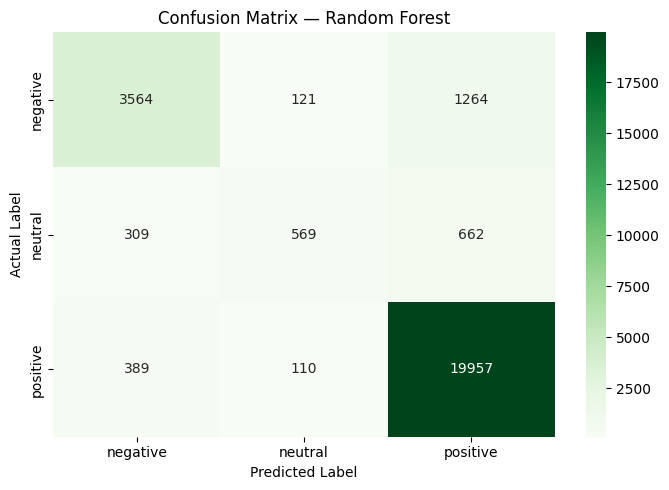

In [9]:
# evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

# dynamically get the exact label names from your trained pipeline
labels = rf_pipeline.classes_

# generate a full report showing Precision, Recall, and F1-Score per class
report = classification_report(y_test, y_pred, target_names=labels)
print("--- Classification Report ---")
print(report)

# build the confusion matrix from actual vs predicted labels
cm = confusion_matrix(y_test, y_pred, labels=labels)

# plot the confusion matrix as a colour heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)

# add axis labels and a title to make the chart readable
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# Q3 Hyperparameter Tuning

# Step 1 - Define the parameter grid

In [18]:
# Import all libraries
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import f1_score, precision_score, recall_score


# Define parameters specifically for Random Forest
# Note: 'rf__' matches the name we gave the Random Forest step in the pipeline earlier
param_grid = {
    'rf__n_estimators': [100, 200, 300],       # Number of trees in the forest
    'rf__max_depth': [None, 10, 20],           # Maximum depth of the trees
    'rf__min_samples_split': [2, 5, 10]        # Minimum samples required to split an internal node
}

# Calculate and print total combinations
total_combos = 1
print("--- Random Forest Parameter Grid ---")
for key, values in param_grid.items():
    total_combos *= len(values)
    print(f" {key}: {values}")

print(f"\nTotal combinations to test: {total_combos} (x5 folds = {total_combos * 5} fits)")

--- Random Forest Parameter Grid ---
 rf__n_estimators: [100, 200, 300]
 rf__max_depth: [None, 10, 20]
 rf__min_samples_split: [2, 5, 10]

Total combinations to test: 27 (x5 folds = 135 fits)


# Step 2 - Run the GridSearchCV

In [14]:
print("Initializing GridSearchCV...")

# Set up the grid search with the Random Forest pipeline
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1,  # Uses all available CPU cores to speed up training
    verbose=2
)

print("Running GridSearchCV (this may take a few minutes)...")
grid_search.fit(X_train, y_train)
print("GridSearchCV complete!")

Initializing GridSearchCV...
Running GridSearchCV (this may take a few minutes)...
Fitting 2 folds for each of 27 candidates, totalling 54 fits
[CV] END rf__max_depth=None, rf__min_samples_split=5, rf__n_estimators=100; total time= 2.7min
[CV] END rf__max_depth=None, rf__min_samples_split=5, rf__n_estimators=100; total time= 2.8min
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=100; total time= 3.7min
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=100; total time= 3.9min
[CV] END rf__max_depth=None, rf__min_samples_split=10, rf__n_estimators=100; total time= 2.0min
[CV] END rf__max_depth=None, rf__min_samples_split=5, rf__n_estimators=200; total time= 4.9min
[CV] END rf__max_depth=None, rf__min_samples_split=10, rf__n_estimators=100; total time= 2.1min
[CV] END rf__max_depth=None, rf__min_samples_split=5, rf__n_estimators=200; total time= 5.0min
[CV] END rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  19.1s
[

# Step 3 - Best parameters found

In [15]:
# Extract the best parameters and cross-validation score
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print("--- Best Hyperparameters Here Is ---")
for param, value in best_params.items():
    print(f" {param}: {value}")

print(f"\nBest Cross-Validation Macro F1-Score: {best_cv_score:.4f}")

--- Best Hyperparameters Here Is ---
 rf__max_depth: None
 rf__min_samples_split: 2
 rf__n_estimators: 200

Best Cross-Validation Macro F1-Score: 0.7191


# Step 4 - Performance of tuned model on the test set

In [16]:
# Predict on the test set using the best model found by GridSearchCV
y_pred_tuned = grid_search.predict(X_test)

# Calculate accuracy
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

# Print the classification report (using dynamic labels to prevent hardcoding errors)
labels = rf_pipeline.classes_

print("--- Tuned Random Forest — Classification Report ---")
print(f"Accuracy: {tuned_accuracy:.4f}\n")
print(classification_report(y_test, y_pred_tuned, target_names=labels))

--- Tuned Random Forest — Classification Report ---
Accuracy: 0.8949

              precision    recall  f1-score   support

    negative       0.84      0.72      0.78      4949
     neutral       0.72      0.37      0.49      1540
    positive       0.91      0.98      0.94     20456

    accuracy                           0.89     26945
   macro avg       0.82      0.69      0.74     26945
weighted avg       0.89      0.89      0.89     26945



# Step 5 - Before and after tuning comparison

In [19]:

# Gather metrics for the original default model (y_pred from earlier)
before = {
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'Macro F1': round(f1_score(y_test, y_pred, average='macro'), 4),
    'Macro Precision': round(precision_score(y_test, y_pred, average='macro'), 4),
    'Macro Recall': round(recall_score(y_test, y_pred, average='macro'), 4)
}

# Gather metrics for the new tuned model (y_pred_tuned)
after = {
    'Accuracy': round(accuracy_score(y_test, y_pred_tuned), 4),
    'Macro F1': round(f1_score(y_test, y_pred_tuned, average='macro'), 4),
    'Macro Precision': round(precision_score(y_test, y_pred_tuned, average='macro'), 4),
    'Macro Recall': round(recall_score(y_test, y_pred_tuned, average='macro'), 4)
}

# Print the comparison table
print("--- Random Forest: Before vs After Tuning ---")
print(f"{'Metric':<20} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 55)

for metric in before:
    diff = round(after[metric] - before[metric], 4)
    # Determine the direction of the arrow
    arrow = "▲" if diff > 0 else ("▼" if diff < 0 else "=")
    print(f"{metric:<20} {before[metric]:>10.4f} {after[metric]:>10.4f} {arrow} {diff:>6.4f}")

--- Random Forest: Before vs After Tuning ---
Metric                   Before      After     Change
-------------------------------------------------------
Accuracy                 0.8940     0.8949 ▲ 0.0009
Macro F1                 0.7343     0.7357 ▲ 0.0014
Macro Precision          0.8198     0.8236 ▲ 0.0038
Macro Recall             0.6884     0.6890 ▲ 0.0006
